## 7.1
Identify the number of support vectors in dependence of the parameter (λ, C, depending on the formulation) on a synthetic dataset, and on the titanic and breast cancer datasets. Repeat the problem with different kernels.

/home/iquadro/Progetti/analisi-dati/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/iquadro/Progetti/analisi-dati/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/iquadro/Progetti/analisi-dati/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/iquadro/Progetti/analisi-dati/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:340: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/iq

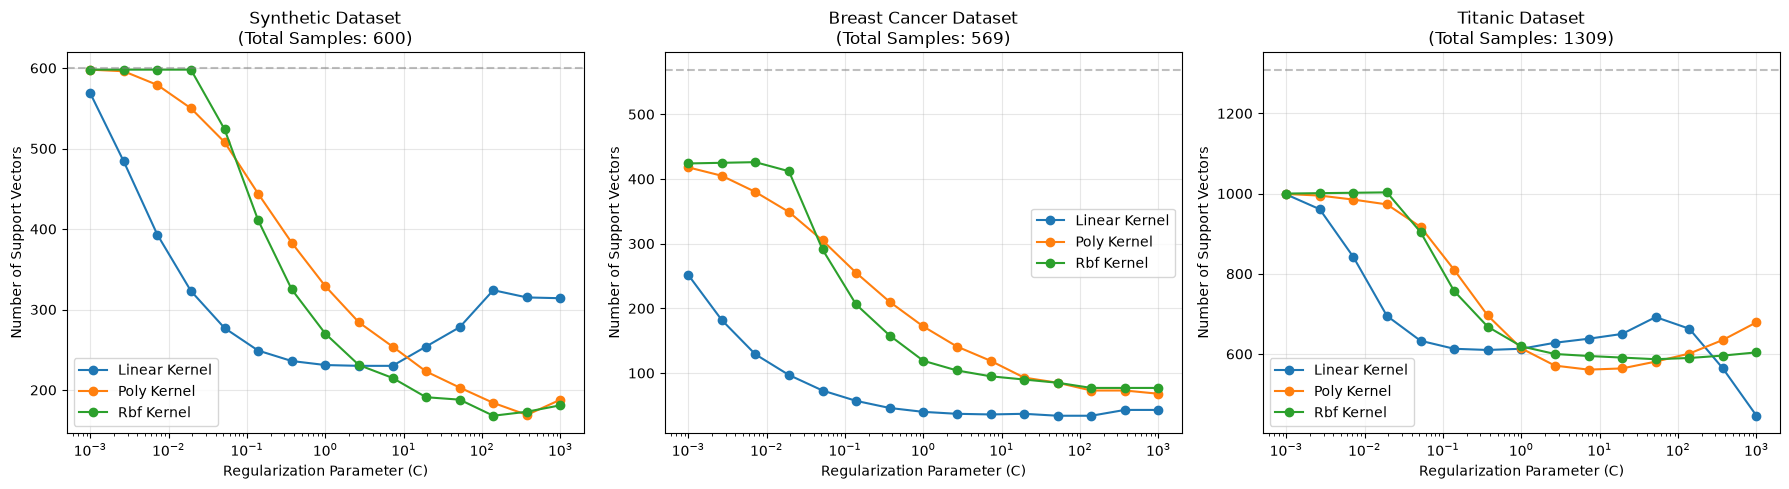

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_classification, load_breast_cancer, fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
import warnings

# Suppress minor warnings from fetch_openml or potential convergence limits
# warnings.filterwarnings('ignore')

def load_and_preprocess_data():
    """Loads and preprocesses the three datasets."""
    datasets = {}

    # 1. Synthetic Dataset
    X_syn, y_syn = make_classification(
        n_samples=600, n_features=10, n_informative=5, n_redundant=2, random_state=42
    )
    # Scale synthetic data
    X_syn = StandardScaler().fit_transform(X_syn)
    datasets['Synthetic'] = (X_syn, y_syn)

    # 2. Breast Cancer Dataset
    cancer = load_breast_cancer()
    X_canc = StandardScaler().fit_transform(cancer.data)
    datasets['Breast Cancer'] = (X_canc, cancer.target)

    # 3. Titanic Dataset
    titanic = fetch_openml('titanic', version=1, as_frame=True)
    df = titanic.frame
    
    # Drop columns with too much missing data or irrelevant string identifiers
    df = df.drop(columns=['name', 'ticket', 'cabin', 'boat', 'body', 'home.dest'])
    
    # Separate features and target
    X_tit = df.drop(columns=['survived'])
    y_tit = df['survived'].astype(int).values

    # Preprocessing pipeline for Titanic's mixed data types
    numeric_features = ['age', 'fare', 'sibsp', 'parch']
    numeric_transformer = make_pipeline(
        SimpleImputer(strategy='median'),
        StandardScaler()
    )

    categorical_features = ['sex', 'embarked', 'pclass']
    categorical_transformer = make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    X_tit_processed = preprocessor.fit_transform(X_tit)
    datasets['Titanic'] = (X_tit_processed, y_tit)

    return datasets

def run_experiment():
    datasets = load_and_preprocess_data()
    
    # Define C values (logarithmic scale from 10^-3 to 10^3)
    C_values = np.logspace(-3, 3, 15)
    kernels = ['linear', 'poly', 'rbf']
    
    # Store results: results[dataset][kernel] = [list of SV counts]
    results = {name: {k: [] for k in kernels} for name in datasets.keys()}

    for dataset_name, (X, y) in datasets.items():
        for kernel in kernels:
            for C in C_values:
                # Initialize and fit SVC
                # Poly kernel defaults to degree=3
                clf = SVC(C=C, kernel=kernel, max_iter=10000, random_state=42)
                clf.fit(X, y)
                
                # Extract total number of support vectors
                n_sv = np.sum(clf.n_support_)
                results[dataset_name][kernel].append(n_sv)
                
    return datasets, C_values, kernels, results

def plot_results(datasets, C_values, kernels, results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
    
    for ax, dataset_name in zip(axes, datasets.keys()):
        total_samples = datasets[dataset_name][0].shape[0]
        
        for kernel in kernels:
            sv_counts = results[dataset_name][kernel]
            ax.plot(C_values, sv_counts, marker='o', label=f'{kernel.capitalize()} Kernel')
            
        ax.set_xscale('log')
        ax.set_title(f'{dataset_name} Dataset\n(Total Samples: {total_samples})')
        ax.set_xlabel('Regularization Parameter (C)')
        ax.set_ylabel('Number of Support Vectors')
        ax.grid(alpha=0.3)
        ax.legend()
        
        # Add a horizontal dashed line indicating the total number of samples
        ax.axhline(total_samples, color='gray', linestyle='--', alpha=0.5, label='Total Samples')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    datasets, C_values, kernels, results = run_experiment()
    plot_results(datasets, C_values, kernels, results)

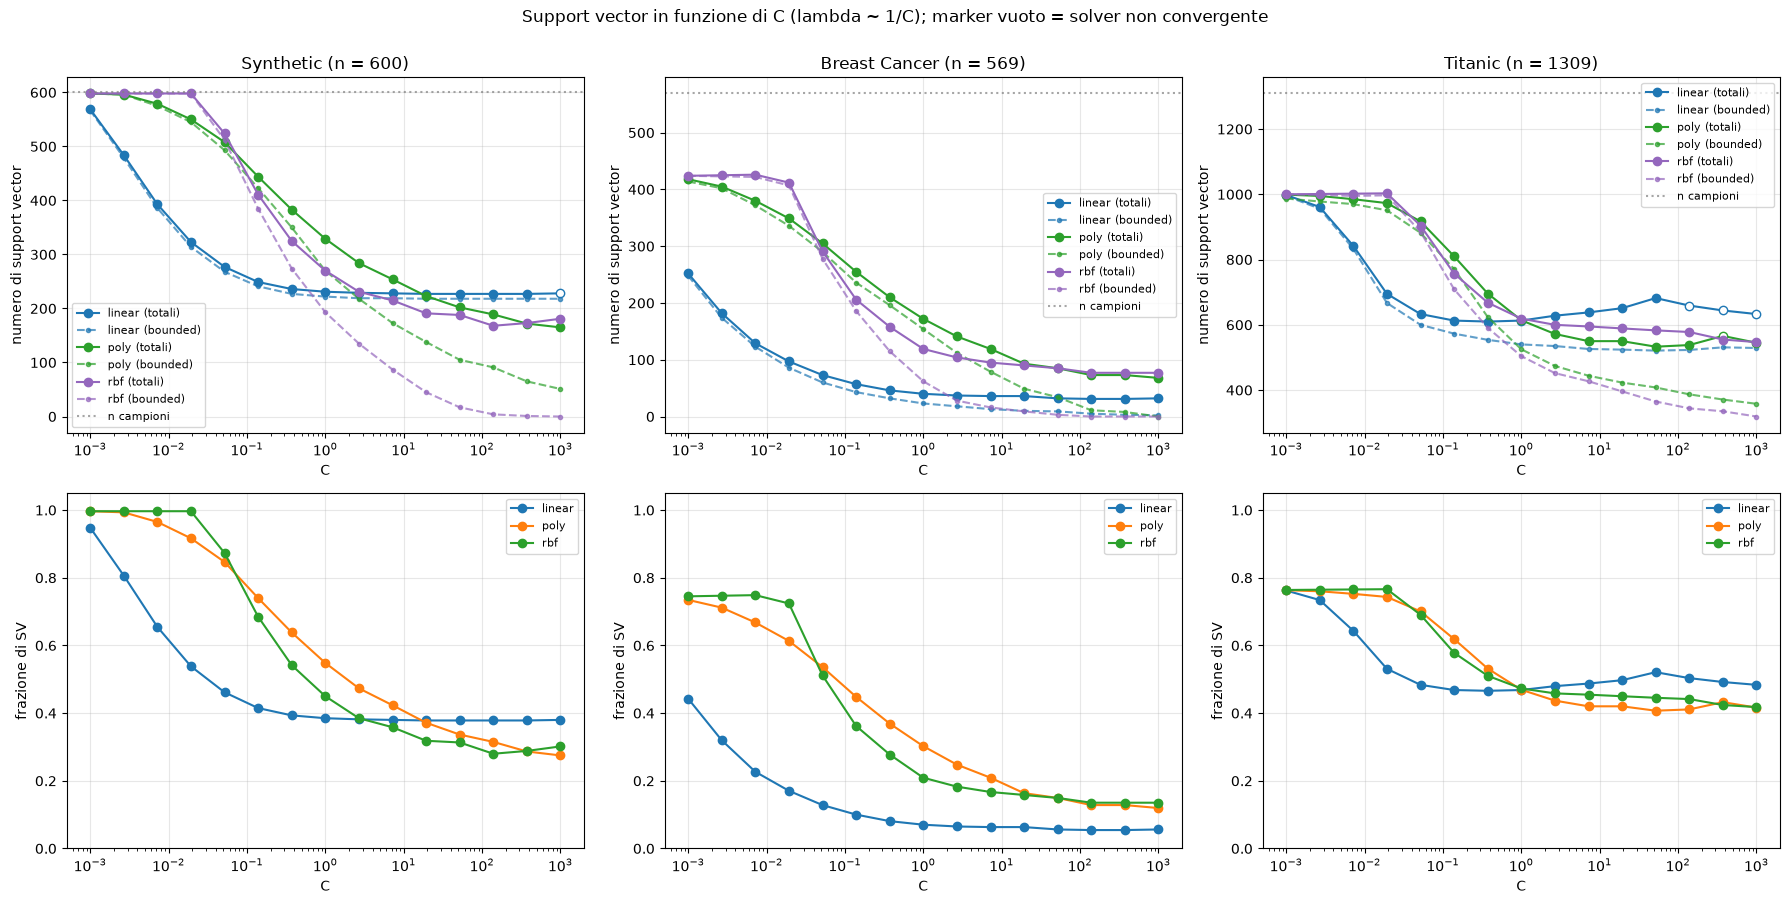

dataset        kernel           C  SV tot  bounded  free   fraz.  conv
----------------------------------------------------------------------
Synthetic      linear       0.001     569      567     2    0.95
Synthetic      linear       1.000     231      222     9    0.39
Synthetic      linear    1000.000     228      218    10    0.38  <-- NON convergente
Synthetic      poly         0.001     598      598     0    1.00
Synthetic      poly         1.000     329      270    59    0.55
Synthetic      poly      1000.000     165       51   114    0.28
Synthetic      rbf          0.001     598      598     0    1.00
Synthetic      rbf          1.000     270      193    77    0.45
Synthetic      rbf       1000.000     181        0   181    0.30
Breast Cancer  linear       0.001     252      248     4    0.44
Breast Cancer  linear       1.000      40       23    17    0.07
Breast Cancer  linear    1000.000      32        2    30    0.06
Breast Cancer  poly         0.001     418      414     4 

In [ ]:
# # --- 7.1 (versione corretta) ---
# # Correzioni rispetto alla cella precedente:
# #   1. max_iter=10000 era troppo basso e troncava il solver senza avvisare: i punti
# #      a C grande erano artefatti. Es. sintetico/lineare/C=1000: 314 SV troncati
# #      contro 227 SV a convergenza. Qui il budget e' alzato a 5*10^6 e, soprattutto,
# #      la mancata convergenza viene RILEVATA e segnalata invece che nascosta.
# #   2. rimosso random_state, ininfluente senza probability=True.
# #   3. separati i SV "bounded" (alpha = C: dentro il margine o mal classificati)
# #      dai SV "free" (0 < alpha < C: esattamente sul margine).
# #   4. riportata anche la frazione di SV, per confrontare dataset di taglia diversa.
# #   5. legend() chiamata dopo axhline, altrimenti la linea di riferimento non
# #      compariva in legenda.
# #
# # Formulazione: nella forma penalizzata il parametro di regolarizzazione e'
# # inversamente proporzionale a C (lambda ~ 1/C). Quindi C piccolo (lambda grande)
# # = margine largo = molti SV; C grande (lambda piccolo) = margine stretto = pochi SV.
# #
# # ATTENZIONE ai punti segnalati come non convergenti (marker vuoto nei grafici):
# # per Titanic con kernel lineare il numero di SV a C grande non si stabilizza
# # nemmeno con 2*10^7 iterazioni (658 -> 633 -> 612 passando da 10^6 a 2*10^7),
# # quindi quei valori vanno letti come indicativi, non come il numero esatto di SV.
# # Il dataset Titanic non e' separabile e a C grande il problema duale e' mal posto.
# # NOTA: questa cella richiede qualche minuto (i fit a C grande sono i piu' lenti).

# import warnings
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.svm import SVC
# from sklearn.exceptions import ConvergenceWarning

# # riusa il loader definito nella cella precedente
# datasets = load_and_preprocess_data()

# C_values = np.logspace(-3, 3, 15)
# kernels = ['linear', 'poly', 'rbf']
# MAX_ITER = 5_000_000

# # results[dataset][kernel] = {'total': [...], 'bounded': [...], 'converged': [...]}
# results = {name: {k: {'total': [], 'bounded': [], 'converged': []} for k in kernels}
#            for name in datasets}

# for dataset_name, (X, y) in datasets.items():
#     for kernel in kernels:
#         for C in C_values:
#             # cattura la ConvergenceWarning del singolo fit invece di ignorarla
#             with warnings.catch_warnings(record=True) as caught:
#                 warnings.simplefilter("always")
#                 clf = SVC(C=C, kernel=kernel, max_iter=MAX_ITER).fit(X, y)
#                 converged = not any(issubclass(w.category, ConvergenceWarning)
#                                     for w in caught)
#             n_total = int(clf.n_support_.sum())
#             # i moltiplicatori duali saturati al bordo (|alpha| = C) sono i bounded SV
#             n_bounded = int(np.sum(np.abs(clf.dual_coef_) >= C * (1 - 1e-6)))
#             results[dataset_name][kernel]['total'].append(n_total)
#             results[dataset_name][kernel]['bounded'].append(n_bounded)
#             results[dataset_name][kernel]['converged'].append(converged)

# fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# for col, dataset_name in enumerate(datasets):
#     n_samples = datasets[dataset_name][0].shape[0]

#     # riga 1: SV totali (tratto pieno) e bounded (tratteggio)
#     ax = axes[0, col]
#     for kernel in kernels:
#         res = results[dataset_name][kernel]
#         conv = np.array(res['converged'])
#         total = np.array(res['total'])
#         line, = ax.plot(C_values, total, marker='o', markevery=list(np.flatnonzero(conv)),
#                         label=f'{kernel} (totali)')
#         # punti non convergenti: marker vuoto, da non prendere alla lettera
#         ax.plot(C_values[~conv], total[~conv], linestyle='none', marker='o',
#                 markerfacecolor='white', markeredgecolor=line.get_color())
#         ax.plot(C_values, res['bounded'], marker='.', linestyle='--',
#                 color=line.get_color(), alpha=0.7, label=f'{kernel} (bounded)')
#     ax.axhline(n_samples, color='gray', linestyle=':', alpha=0.7, label='n campioni')
#     ax.set_xscale('log')
#     ax.set_title(f'{dataset_name} (n = {n_samples})')
#     ax.set_xlabel('C')
#     ax.set_ylabel('numero di support vector')
#     ax.grid(alpha=0.3)
#     ax.legend(fontsize=8)  # dopo axhline, cosi' la linea grigia compare in legenda

#     # riga 2: frazione di SV, comparabile tra dataset di taglia diversa
#     ax = axes[1, col]
#     for kernel in kernels:
#         frac = np.array(results[dataset_name][kernel]['total']) / n_samples
#         ax.plot(C_values, frac, marker='o', label=kernel)
#     ax.set_xscale('log')
#     ax.set_ylim(0, 1.05)
#     ax.set_xlabel('C')
#     ax.set_ylabel('frazione di SV')
#     ax.grid(alpha=0.3)
#     ax.legend(fontsize=8)

# fig.suptitle('Support vector in funzione di C (lambda ~ 1/C); '
#              'marker vuoto = solver non convergente', y=1.0)
# plt.tight_layout()
# plt.show()

# # tabella riassuntiva: estremi e centro della griglia di C
# hdr = f"{'dataset':<15}{'kernel':<8}{'C':>10}{'SV tot':>8}{'bounded':>9}{'free':>6}{'fraz.':>8}  conv"
# print(hdr)
# print('-' * len(hdr))
# for dataset_name in datasets:
#     n_samples = datasets[dataset_name][0].shape[0]
#     for kernel in kernels:
#         res = results[dataset_name][kernel]
#         for i in (0, len(C_values) // 2, len(C_values) - 1):
#             tot, bnd = res['total'][i], res['bounded'][i]
#             flag = '' if res['converged'][i] else '  <-- NON convergente'
#             print(f"{dataset_name:<15}{kernel:<8}{C_values[i]:>10.3f}"
#                   f"{tot:>8}{bnd:>9}{tot - bnd:>6}{tot / n_samples:>8.2f}{flag}")

# n_bad = sum(not c for d in results.values() for k in d.values() for c in k['converged'])
# print(f"\nFit non convergenti entro max_iter={MAX_ITER:,}: {n_bad} su "
#       f"{len(datasets) * len(kernels) * len(C_values)}")
